# 산학프로젝트
**제조 공정 품질 불량 예측**

# 04 Model Improvement

## import

In [1]:
import pandas as pd
import numpy as np
import os

## 경로설정

In [2]:
os.chdir("data")

## 데이터 불러오기

In [39]:
labeled=pd.read_csv('labeled_data.csv', encoding='utf-8')
result_df=pd.read_csv('03_Baseline_Modeling_Result.csv')

In [40]:
labeled.head()

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,...,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
0,5f8928bb9c0189cc666ef19b,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,...,24.799999,27.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5f8928de9c0189cc666ef20b,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.60,...,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5f8928df9c0189cc666ef213,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,...,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5f8928f39c0189cc666ef25e,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.59,...,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5f8928f59c0189cc666ef265,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,...,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
result_df

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109


## 모델 개선 실험

In [42]:
# 개선 실험 공통 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn import set_config
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report
from xgboost import XGBClassifier

set_config(display='text')

### 클래스 가중치

#### 데이터 전처리

In [43]:
def info_df(df):
    info=pd.DataFrame(
        {
            "Columns": df.columns,
            "Non-Null Count": df.notna().sum().values,
            "Dtype": df.dtypes.values
        }
    )
    return info

In [44]:
info_df(labeled)

,Columns,Non-Null Count,Dtype
0,_id,7996,str
1,TimeStamp,7996,str
2,PART_FACT_PLAN_DATE,7996,str
3,PART_FACT_SERIAL,7996,int64
4,PART_NAME,7996,str
5,EQUIP_CD,7996,str
6,EQUIP_NAME,7996,str
7,PassOrFail,7996,str
8,Reason,71,str
9,Injection_Time,7996,float64


In [45]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2',
               'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
               'PART_NAME', 'Reason', 'Switch_Over_Position', 'TimeStamp', '_id']

final_df=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
final_df['PassOrFail']=final_df['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

final_df.shape

(5230, 25)

In [46]:
final_df.head()

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,9.59,4.47,16.92,59.520000,7.13,653.409973,68.849998,647.98999,55.400002,...,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,66.300003,24.799999,27.5
1,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,...,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
2,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,...,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
3,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,...,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
4,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,...,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6


In [47]:
# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(final_df.drop(columns='PassOrFail'), final_df['PassOrFail'], test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

print("데이터 분할 결과")
print(f'X_Train: {x_train.shape}, Y_Train: {y_train.shape}')
print(f'X_Test: {x_test.shape}, Y_Test: {y_test.shape}')

# 데이터 스케일링
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

데이터 분할 결과
X_Train: (4184, 24), Y_Train: (4184,)
X_Test: (1046, 24), Y_Test: (1046,)


#### 모델 학습

In [48]:
balanced_rf=RandomForestClassifier(n_estimators=1000, class_weight='balanced', min_samples_leaf=2, n_jobs=1, random_state=0)
balanced_rf.fit(x_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=1000, n_jobs=1, random_state=0)

#### 예측

In [49]:
pred_balanced_rf=balanced_rf.predict(x_test_scaled)
balanced_rf_acc=balanced_rf.score(x_test_scaled, y_test)
print(f'Accuracy: {balanced_rf_acc}')

balanced_rf_prob = balanced_rf.predict_proba(x_test_scaled)
precision, recall, thresholds = precision_recall_curve(y_test, balanced_rf_prob[:, 1])
ap_score = average_precision_score(y_test, balanced_rf_prob[:, 1])
print(f'Average Precision: {ap_score}')

Accuracy: 0.982791586998088
Average Precision: 0.3517577041256616


In [50]:
print(classification_report(y_test, pred_balanced_rf, target_names=['양품', '불량']))

              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.35      0.58      0.44        12

    accuracy                           0.98      1046
   macro avg       0.67      0.79      0.71      1046
weighted avg       0.99      0.98      0.98      1046



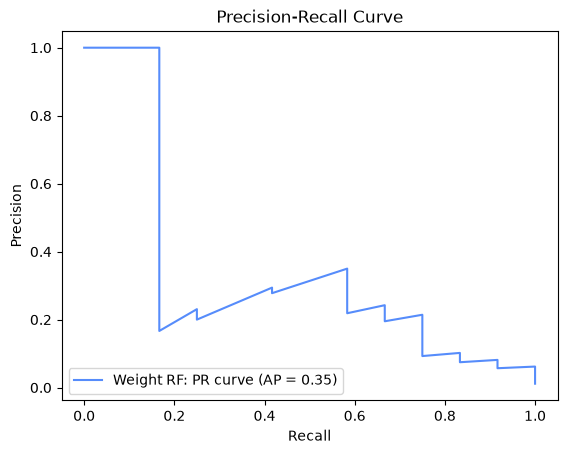

In [51]:
plt.figure()
plt.plot(recall, precision, label=f'Weight RF: PR curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [52]:
report=classification_report(y_test, pred_balanced_rf, target_names=['양품', '불량'], output_dict=True)

precision_defect=report['불량']['precision']
recall_defect=report['불량']['recall']
f1_defect=report['불량']['f1-score']
model='Random Forest Balanced'
result_dict={'Model': model, 'Defect Precision': precision_defect, 'Defect Recall': recall_defect,
              'Defect F1 Score': f1_defect, 'Average Precision': ap_score}
result=pd.DataFrame([result_dict])
result_df=pd.concat([result_df, result], ignore_index=True)
result_df

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
0,Random Forest Balanced,0.350000,0.583333,0.437500,0.351758


### SMOTE: Sampling

#### 데이터 전처리

In [53]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2',
               'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
               'PART_NAME', 'Reason', 'Switch_Over_Position', 'TimeStamp', '_id']

final_df=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
final_df['PassOrFail']=final_df['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

final_df.shape

(5230, 25)

In [55]:
# 데이터 분할
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [56]:
# 학습데이터에 SMOTE 적용
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 24) (4184,)
After
(8272, 24) (8272,)


In [57]:
x_train_smote[:5]

array([[ 0.57952796,  0.60644569,  0.52738193, -0.52167709,  0.54474781,
        -0.50994252,  0.59299723,  0.57103517, -0.57798195,  0.44896415,
         0.85948431,  0.00222524,  0.62207941, -0.49720396,  0.02837096,
        -0.530315  , -0.34370475, -0.48078644, -0.0769271 , -0.5576974 ,
        -0.72827301, -0.41907038, -0.63274298, -0.58366175],
       [ 0.55213645,  0.54011872,  0.66861983, -0.60138796,  0.61205668,
        -0.59269444,  0.57574077,  0.57103517, -0.54260724,  0.44896415,
         0.86025568, -0.2322233 ,  0.54101033, -0.50977371, -0.07071494,
        -0.50905482, -0.49590621, -0.61068817, -0.79476815, -0.46731914,
        -0.63630161,  0.83169162,  0.13041552, -0.16182014],
       [ 0.57404955,  0.59981286,  0.53915194, -0.52167709,  0.54474781,
        -0.53752649,  0.59299723,  0.57103517, -0.57476611, -0.89664884,
         0.85948431,  0.00222524,  0.62207941, -0.50977371, -0.00465725,
        -0.42402056, -0.4741622 , -0.50243783,  0.10253316, -0.53510197,
  

#### 모델 학습

In [59]:
# 학습 모델 저장
model_dict={}

In [60]:
# Random Forest
smote_rf=RandomForestClassifier(n_estimators=1000, random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest']=smote_rf

# Bagging
smote_bag=BaggingClassifier(n_estimators=1000, random_state=0)
smote_bag.fit(x_train_smote, y_train_smote)
model_dict['Bagging']=smote_bag

# XGBoost
smote_xgb=XGBClassifier(n_estimators=1000, random_state=0)
smote_xgb.fit(x_train_smote, y_train_smote)
model_dict['XGBoost']=smote_xgb

#### 예측

RandomForest
Accuracy: 0.9818355640535373
Average Precision: 0.45018302327062243
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.29      0.42      0.34        12

    accuracy                           0.98      1046
   macro avg       0.64      0.70      0.67      1046
weighted avg       0.99      0.98      0.98      1046

Bagging
Accuracy: 0.9799235181644359
Average Precision: 0.4452438314400868
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.98      0.99      1034
          불량       0.30      0.58      0.40        12

    accuracy                           0.98      1046
   macro avg       0.65      0.78      0.69      1046
weighted avg       0.99      0.98      0.98      1046

XGBoost
Accuracy: 0.9837476099426387
Average Precision: 0.3738407981735379
Classification Report
              precision    recall  f1-score   sup

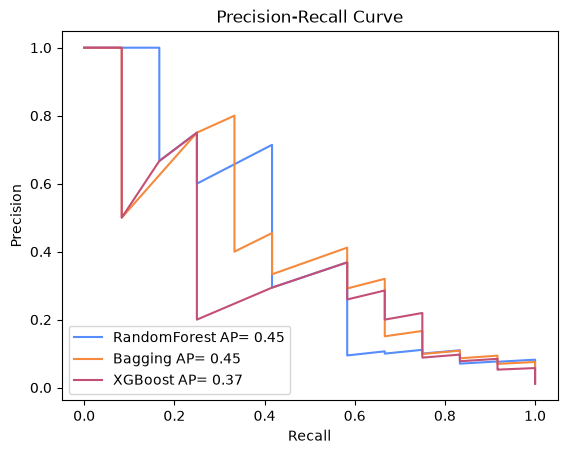

In [61]:
# 저장한 학습 모델 불러와서 예측
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report
plt.figure()
for model in model_dict:
    x_pred=model_dict[model].predict(x_test_scaled)
    y_prob=model_dict[model].predict_proba(x_test_scaled)
    acc=model_dict[model].score(x_test_scaled, y_test)
    ap_score=average_precision_score(y_test, y_prob[:, 1])
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob[:, 1])

    print("=" * 80)
    print(model)
    print("=" * 80)
    print(f'Accuracy: {acc}')
    print(f'Average Precision: {ap_score}')
    print("Classification Report")
    print(classification_report(y_test, x_pred, target_names=['양품', '불량']))
    plt.plot(recall, precision, label=f'{model} AP= {ap_score:.2f}')

    report=classification_report(y_test, x_pred, target_names=['양품', '불량'], output_dict=True)
    precision_defect=report['불량']['precision']
    recall_defect=report['불량']['recall']
    f1_defect=report['불량']['f1-score']
    result_dict={'Model': f'{model} SMOTE', 'Defect Precision': precision_defect, 'Defect Recall': recall_defect,
              'Defect F1 Score': f1_defect, 'Average Precision': ap_score}
    df=pd.DataFrame([result_dict])
    result_df=pd.concat([result_df, df], ignore_index=True)


plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [62]:
result_df

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
0,Random Forest Balanced,0.350000,0.583333,0.437500,0.351758
0,RandomForest SMOTE,0.294118,0.416667,0.344828,0.450183
0,Bagging SMOTE,0.304348,0.583333,0.400000,0.445244
0,XGBoost SMOTE,0.368421,0.583333,0.451613,0.373841


#### SMOTE 파라미터 조정

#### 데이터 전처리

In [63]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2',
               'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
               'PART_NAME', 'Reason', 'Switch_Over_Position', 'TimeStamp', '_id']

final_df=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
final_df['PassOrFail']=final_df['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

# 데이터 분할
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

# 스케일링
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# SMOTE Sampling_strategy
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 24) (4184,)
After
(4549, 24) (4549,)


#### 모델 학습

In [64]:
# 학습 모델 저장
model_dict={}

# Random Forest
smote_rf=RandomForestClassifier(n_estimators=1000, random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest']=smote_rf

# Bagging
smote_bag=BaggingClassifier(n_estimators=1000, random_state=0)
smote_bag.fit(x_train_smote, y_train_smote)
model_dict['Bagging']=smote_bag

# XGBoost
smote_xgb=XGBClassifier(n_estimators=1000, random_state=0)
smote_xgb.fit(x_train_smote, y_train_smote)
model_dict['XGBoost']=smote_xgb

#### 예측

RandomForest
Accuracy: 0.9837476099426387
Average Precision: 0.43609974019232134
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12

    accuracy                           0.98      1046
   macro avg       0.68      0.79      0.72      1046
weighted avg       0.99      0.98      0.99      1046

Bagging
Accuracy: 0.9837476099426387
Average Precision: 0.4193462039417067
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12

    accuracy                           0.98      1046
   macro avg       0.68      0.79      0.72      1046
weighted avg       0.99      0.98      0.99      1046

XGBoost
Accuracy: 0.9837476099426387
Average Precision: 0.3009241456093764
Classification Report
              precision    recall  f1-score   sup

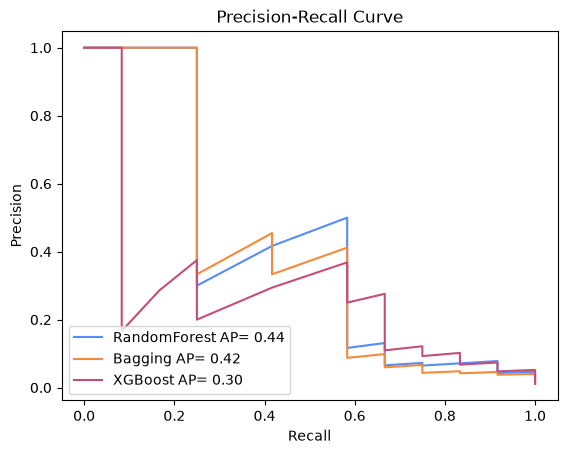

In [65]:
# 저장한 학습 모델 불러와서 예측
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report
plt.figure()
for model in model_dict:
    x_pred=model_dict[model].predict(x_test_scaled)
    y_prob=model_dict[model].predict_proba(x_test_scaled)
    acc=model_dict[model].score(x_test_scaled, y_test)
    ap_score=average_precision_score(y_test, y_prob[:, 1])
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob[:, 1])

    print("=" * 80)
    print(model)
    print("=" * 80)
    print(f'Accuracy: {acc}')
    print(f'Average Precision: {ap_score}')
    print("Classification Report")
    print(classification_report(y_test, x_pred, target_names=['양품', '불량']))
    plt.plot(recall, precision, label=f'{model} AP= {ap_score:.2f}')

    report=classification_report(y_test, x_pred, target_names=['양품', '불량'], output_dict=True)
    precision_defect=report['불량']['precision']
    recall_defect=report['불량']['recall']
    f1_defect=report['불량']['f1-score']
    result_dict={'Model': f'{model} SMOTE St=0.1', 'Defect Precision': precision_defect, 'Defect Recall': recall_defect,
              'Defect F1 Score': f1_defect, 'Average Precision': ap_score}
    df=pd.DataFrame([result_dict])
    result_df=pd.concat([result_df, df], ignore_index=True)


plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [66]:
result_df

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
3,Random Forest Balanced,0.350000,0.583333,0.437500,0.351758
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.450183
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.445244
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.373841
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.436100
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.419346
9,XGBoost SMOTE St=0.1,0.368421,0.583333,0.451613,0.300924


### 제품명 변수 추가

#### 데이터 전처리

In [68]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 구분하는 변수 추가
drop_part['Part']=drop_part['PART_NAME'].str[:3]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11',
              'Mold_Temperature_12', 'Mold_Temperature_2','Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7',
              'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL','PART_NAME', 'Reason',
              'Switch_Over_Position', 'TimeStamp', '_id']

drop_col=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
drop_col['PassOrFail']=drop_col['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

#### 모델 학습

In [69]:
# Random Forest
rf=RandomForestClassifier(n_estimators=1000, random_state=0)
rf.fit(x_train_scaled, y_train)

RandomForestClassifier(n_estimators=1000, random_state=0)

#### 예측

In [70]:
pred_rf=rf.predict(x_test_scaled)
rf_acc=rf.score(x_test_scaled, y_test)
print(f'Accuracy: {rf_acc}')

rf_prob = rf.predict_proba(x_test_scaled)
precision, recall, thresholds = precision_recall_curve(y_test, rf_prob[:, 1])
ap_score = average_precision_score(y_test, rf_prob[:, 1])
print(f'Average Precision: {ap_score}')

print(classification_report(y_test, pred_rf, target_names=['양품', '불량']))

Accuracy: 0.9818355640535373
Average Precision: 0.44825143656946304
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.29      0.42      0.34        12

    accuracy                           0.98      1046
   macro avg       0.64      0.70      0.67      1046
weighted avg       0.99      0.98      0.98      1046



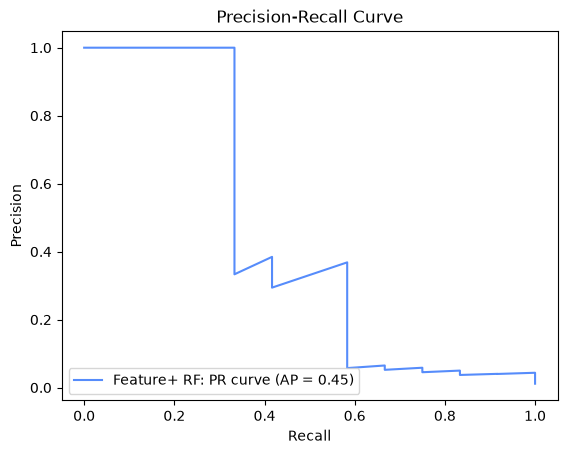

In [71]:
plt.figure()
plt.plot(recall, precision, label=f'Feature+ RF: PR curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [72]:
report=classification_report(y_test, pred_rf, target_names=['양품', '불량'], output_dict=True)

precision_defect=report['불량']['precision']
recall_defect=report['불량']['recall']
f1_defect=report['불량']['f1-score']
model='Random Forest PART_NAME'
result_dict={'Model': model, 'Defect Precision': precision_defect, 'Defect Recall': recall_defect,
              'Defect F1 Score': f1_defect, 'Average Precision': ap_score}
result=pd.DataFrame([result_dict])
result_df=pd.concat([result_df, result], ignore_index=True)
result_df

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
3,Random Forest Balanced,0.350000,0.583333,0.437500,0.351758
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.450183
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.445244
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.373841
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.436100
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.419346
9,XGBoost SMOTE St=0.1,0.368421,0.583333,0.451613,0.300924


#### 데이터 전처리

In [74]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 / LH, RH 구분하는 변수 추가
drop_part['Part']=drop_part['PART_NAME'].str[:3]+drop_part['PART_NAME'].str[-2:]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11',
              'Mold_Temperature_12', 'Mold_Temperature_2','Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7',
              'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL','PART_NAME', 'Reason',
              'Switch_Over_Position', 'TimeStamp', '_id']

drop_col=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
drop_col['PassOrFail']=drop_col['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(final_df.drop(columns='PassOrFail'), final_df['PassOrFail'], test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

#### 모델 학습

In [75]:
# Random Forest
rf=RandomForestClassifier(n_estimators=1000, random_state=0)
rf.fit(x_train_scaled, y_train)

RandomForestClassifier(n_estimators=1000, random_state=0)

#### 예측

In [76]:
pred_rf=rf.predict(x_test_scaled)
rf_acc=rf.score(x_test_scaled, y_test)
print(f'Accuracy: {rf_acc}')

rf_prob = rf.predict_proba(x_test_scaled)
precision, recall, thresholds = precision_recall_curve(y_test, rf_prob[:, 1])
ap_score = average_precision_score(y_test, rf_prob[:, 1])
print(f'Average Precision: {ap_score}')

print(classification_report(y_test, pred_rf, target_names=['양품', '불량']))

Accuracy: 0.9875717017208413
Average Precision: 0.5306388026492072
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.45      0.42      0.43        12

    accuracy                           0.99      1046
   macro avg       0.72      0.71      0.71      1046
weighted avg       0.99      0.99      0.99      1046



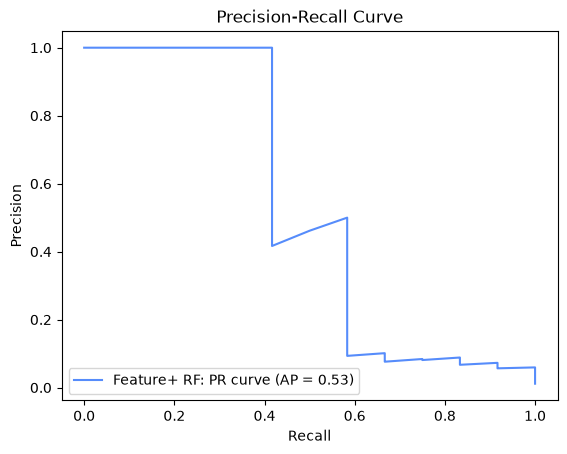

In [77]:
plt.figure()
plt.plot(recall, precision, label=f'Feature+ RF: PR curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [78]:
report=classification_report(y_test, pred_rf, target_names=['양품', '불량'], output_dict=True)

precision_defect=report['불량']['precision']
recall_defect=report['불량']['recall']
f1_defect=report['불량']['f1-score']
model='Random Forest PART_NAME_2'
result_dict={'Model': model, 'Defect Precision': precision_defect, 'Defect Recall': recall_defect,
              'Defect F1 Score': f1_defect, 'Average Precision': ap_score}
result=pd.DataFrame([result_dict])
result_df=pd.concat([result_df, result], ignore_index=True)
result_df

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
3,Random Forest Balanced,0.350000,0.583333,0.437500,0.351758
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.450183
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.445244
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.373841
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.436100
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.419346
9,XGBoost SMOTE St=0.1,0.368421,0.583333,0.451613,0.300924


# 여기부터 수정!

### PART_NAME + Class Weight

In [96]:
drop_part['Part']=drop_part['PART_NAME'].str[:3]+drop_part['PART_NAME'].str[-2:]
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10',
              'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2', 'Mold_Temperature_5',
              'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 
              'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'Reason', 'Switch_Over_Position', 'PART_NAME',
              'TimeStamp', '_id']

drop_col=drop_part.drop(columns=drop_columns)

drop_col['PassOrFail']=drop_col['PassOrFail'].map({'Y':0, 'N':1})

final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

x_train, x_test, y_train, y_test=train_test_split(final_df.drop(columns='PassOrFail'), final_df['PassOrFail'], test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

rf=RandomForestClassifier(n_estimators=1000, class_weight='balanced', min_samples_leaf=2, n_jobs=1,random_state=0)
rf.fit(x_train_scaled, y_train)

pred_rf=rf.predict(x_test_scaled)
rf_acc=rf.score(x_test_scaled, y_test)
print(f'Accuracy: {rf_acc}')

rf_prob = rf.predict_proba(x_test_scaled)
precision, recall, thresholds = precision_recall_curve(y_test, rf_prob[:, 1])
ap_score = average_precision_score(y_test, rf_prob[:, 1])
print(f'Average Precision: {ap_score}')
print(classification_report(y_test, pred_rf, target_names=['양품', '불량']))

Accuracy: 0.988527724665392
Average Precision: 0.5734219926010969
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.50      0.67      0.57        12

    accuracy                           0.99      1046
   macro avg       0.75      0.83      0.78      1046
weighted avg       0.99      0.99      0.99      1046



### SMOTE + PART_NAME

In [15]:
drop_part['Part']=drop_part['PART_NAME'].str[:3]+drop_part['PART_NAME'].str[-2:]
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10',
              'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2', 'Mold_Temperature_5',
              'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 
              'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'Reason', 'Switch_Over_Position', 'PART_NAME',
              'TimeStamp', '_id']

drop_col=drop_part.drop(columns=drop_columns)

drop_col['PassOrFail']=drop_col['PassOrFail'].map({'Y':0, 'N':1})

final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(final_df.drop(columns='PassOrFail'), final_df['PassOrFail'], test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

from imblearn.over_sampling import SMOTE
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 27) (4184,)
After
(4549, 27) (4549,)


In [18]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from xgboost import XGBClassifier
# 학습 모델 저장
model_dict={}

# Random Forest
smote_rf=RandomForestClassifier(n_estimators=1000, random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest']=smote_rf

# Bagging
smote_bag=BaggingClassifier(n_estimators=1000, random_state=0)
smote_bag.fit(x_train_smote, y_train_smote)
model_dict['Bagging']=smote_bag

# XGBoost
smote_xgb=XGBClassifier(n_estimators=1000, random_state=0)
smote_xgb.fit(x_train_smote, y_train_smote)
model_dict['XGBoost']=smote_xgb

# 저장된 모델 확인
model_dict

{'RandomForest': RandomForestClassifier(n_estimators=1000, random_state=0),
 'Bagging': BaggingClassifier(n_estimators=1000, random_state=0),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=1000,
               n_jobs=None, num_parallel_tree=None, ...)}

RandomForest
Accuracy: 0.9894837476099426
Average Precision: 0.649229117934154
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.54      0.58      0.56        12

    accuracy                           0.99      1046
   macro avg       0.77      0.79      0.78      1046
weighted avg       0.99      0.99      0.99      1046

Bagging
Accuracy: 0.988527724665392
Average Precision: 0.6253139675766879
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.50      0.58      0.54        12

    accuracy                           0.99      1046
   macro avg       0.75      0.79      0.77      1046
weighted avg       0.99      0.99      0.99      1046

XGBoost
Accuracy: 0.9904397705544933
Average Precision: 0.5275789783103119
Classification Report
              precision    recall  f1-score   suppor

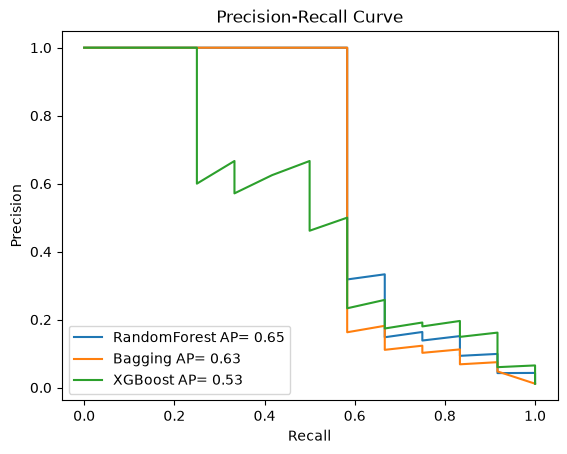

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report

# 저장한 학습 모델 불러와서 예측
plt.figure()
for model in model_dict:
    x_pred=model_dict[model].predict(x_test_scaled)
    y_prob=model_dict[model].predict_proba(x_test_scaled)
    acc=model_dict[model].score(x_test_scaled, y_test)
    ap_score=average_precision_score(y_test, y_prob[:, 1])
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob[:, 1])

    print("=" * 80)
    print(model)
    print("=" * 80)
    print(f'Accuracy: {acc}')
    print(f'Average Precision: {ap_score}')
    print("Classification Report")
    print(classification_report(y_test, x_pred, target_names=['양품', '불량']))

    plt.plot(recall, precision, label=f'{model} AP= {ap_score:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [21]:
importance_df=pd.DataFrame({'Feature':x_train.columns, 'Importance':model_dict['RandomForest'].feature_importances_}).sort_values('Importance', ascending=False)
importance_df

,Feature,Importance
5,Cushion_Position,0.077654
8,Max_Injection_Speed,0.063298
4,Clamp_Close_Time,0.058119
11,Max_Injection_Pressure,0.054639
22,Mold_Temperature_3,0.051430
26,Part_RG3RH,0.050146
19,Barrel_Temperature_5,0.047869
14,Average_Back_Pressure,0.046461
23,Mold_Temperature_4,0.046065
1,Filling_Time,0.043781


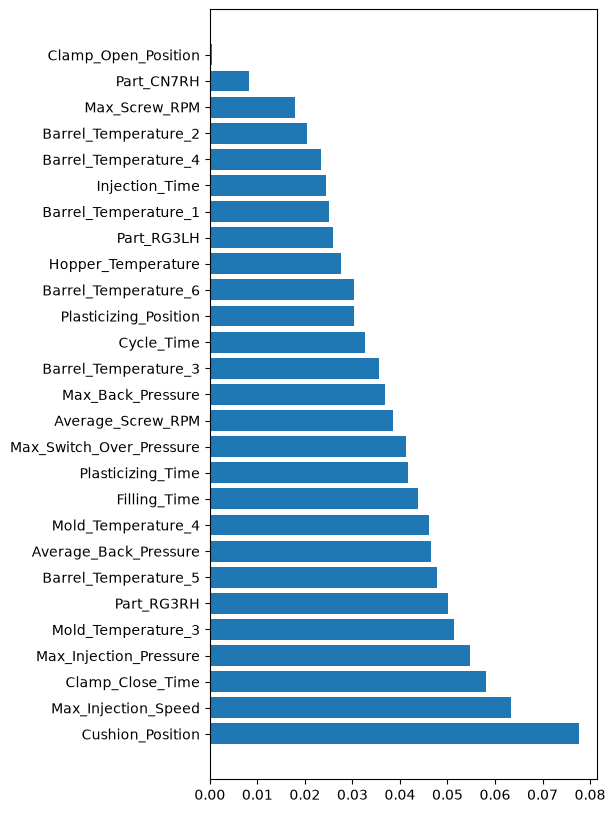

In [22]:
plt.figure(figsize=(5, 10))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.show()

### SMOTE + Class Weight

In [120]:
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]
# 불필요한 컬럼 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2',
               'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
               'PART_NAME', 'Reason', 'Switch_Over_Position', 'TimeStamp', '_id']

final_df=drop_part.drop(columns=drop_columns)

final_df['PassOrFail']=final_df['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

x_train, x_test, y_train, y_test=train_test_split(final_df.drop(columns='PassOrFail'), final_df['PassOrFail'], test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)


Before
(4184, 24) (4184,)
After
(4549, 24) (4549,)


In [121]:
# 학습 모델 저장
model_dict={}

# Random Forest
smote_rf=RandomForestClassifier(n_estimators=1000, class_weight='balanced', min_samples_leaf=2, n_jobs=1,random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest']=smote_rf

# 저장된 모델 확인
model_dict

{'RandomForest': RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                        n_estimators=1000, n_jobs=1, random_state=0)}

RandomForest
Accuracy: 0.982791586998088
Average Precision: 0.4070254235202239
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.35      0.58      0.44        12

    accuracy                           0.98      1046
   macro avg       0.67      0.79      0.71      1046
weighted avg       0.99      0.98      0.98      1046



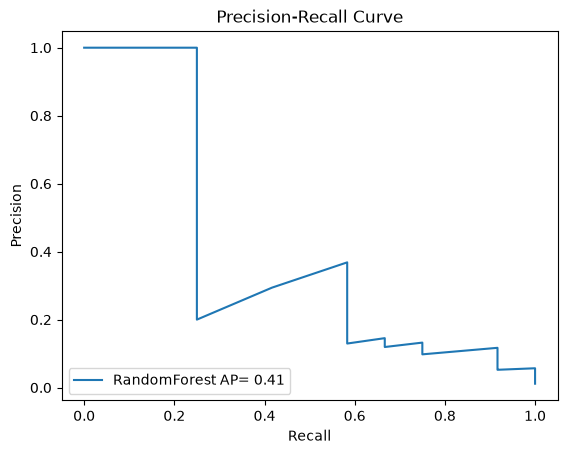

In [122]:
# 저장한 학습 모델 불러와서 예측
plt.figure()
for model in model_dict:
    x_pred=model_dict[model].predict(x_test_scaled)
    y_prob=model_dict[model].predict_proba(x_test_scaled)
    acc=model_dict[model].score(x_test_scaled, y_test)
    ap_score=average_precision_score(y_test, y_prob[:, 1])
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob[:, 1])

    print("=" * 80)
    print(model)
    print("=" * 80)
    print(f'Accuracy: {acc}')
    print(f'Average Precision: {ap_score}')
    print("Classification Report")
    print(classification_report(y_test, x_pred, target_names=['양품', '불량']))

    plt.plot(recall, precision, label=f'{model} AP= {ap_score:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

### SMOTE + PART_NAME + Class Weight

In [124]:
drop_part['Part']=drop_part['PART_NAME'].str[:3]+drop_part['PART_NAME'].str[-2:]
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10',
              'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2', 'Mold_Temperature_5',
              'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 
              'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'Reason', 'Switch_Over_Position', 'PART_NAME',
              'TimeStamp', '_id']

drop_col=drop_part.drop(columns=drop_columns)

drop_col['PassOrFail']=drop_col['PassOrFail'].map({'Y':0, 'N':1})

final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)

x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 27) (4184,)
After
(4549, 27) (4549,)


In [117]:
# 학습 모델 저장
model_dict={}

# Random Forest
smote_rf=RandomForestClassifier(n_estimators=1000, class_weight='balanced', min_samples_leaf=2, n_jobs=1,random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest']=smote_rf

# 저장된 모델 확인
model_dict

{'RandomForest': RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                        n_estimators=1000, n_jobs=1, random_state=0)}

RandomForest
Accuracy: 0.98565965583174
Average Precision: 0.5770654296491787
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.41      0.58      0.48        12

    accuracy                           0.99      1046
   macro avg       0.70      0.79      0.74      1046
weighted avg       0.99      0.99      0.99      1046



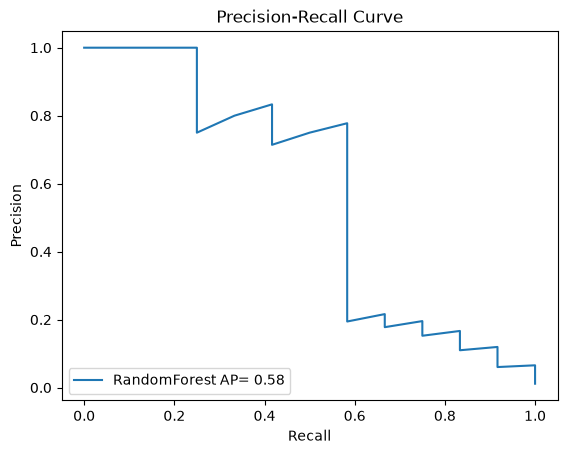

In [118]:
# 저장한 학습 모델 불러와서 예측
plt.figure()
for model in model_dict:
    x_pred=model_dict[model].predict(x_test_scaled)
    y_prob=model_dict[model].predict_proba(x_test_scaled)
    acc=model_dict[model].score(x_test_scaled, y_test)
    ap_score=average_precision_score(y_test, y_prob[:, 1])
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob[:, 1])

    print("=" * 80)
    print(model)
    print("=" * 80)
    print(f'Accuracy: {acc}')
    print(f'Average Precision: {ap_score}')
    print("Classification Report")
    print(classification_report(y_test, x_pred, target_names=['양품', '불량']))

    plt.plot(recall, precision, label=f'{model} AP= {ap_score:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

### 파생변수 추가

In [43]:
drop_part['Part']=drop_part['PART_NAME'].str[:3]+drop_part['PART_NAME'].str[-2:]
sort_df=drop_part.copy().sort_values('TimeStamp', ignore_index=True)

In [45]:
# 불필요한 컬럼 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2',
               'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
                'Reason', 'Switch_Over_Position', 'TimeStamp', '_id']

final_df=sort_df.drop(columns=drop_columns)

final_df = pd.get_dummies(data = final_df, columns = ['Part'], drop_first=True)

In [46]:
final_df['PassOrFail']=final_df['PassOrFail'].map({'Y':0, 'N':1})

final_df['Barrel_Temp_Range']=(final_df[[f'Barrel_Temperature_{i}' for i in range(1, 7)]].max(axis=1) 
                                      - final_df[[f'Barrel_Temperature_{i}' for i in range(1, 7)]].min(axis=1))

final_df['Barrel_Temp_Std'] = final_df[[f'Barrel_Temperature_{i}' for i in range(1, 7)]].std(axis=1)

final_df['Mold_Temp_Range']=(final_df[[f'Mold_Temperature_{i}' for i in range(3, 5)]].max(axis=1) 
                                      - final_df[[f'Barrel_Temperature_{i}' for i in range(1, 7)]].min(axis=1))

final_df['Mold_Temp_Std'] = final_df[[f'Mold_Temperature_{i}' for i in range(3, 5)]].std(axis=1)

In [47]:
for col in ['Injection_Time', 'Cycle_Time',
            'Max_Injection_Pressure', 'Cushion_Position']:
    final_df[f'{col}_diff'] = final_df[col].diff()
    final_df[f'{col}_rolling_mean_5'] = final_df.groupby(['EQUIP_CD', 'PART_NAME'])[col].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    final_df[f'{col}_rolling_std_5'] = final_df.groupby(['EQUIP_CD', 'PART_NAME'])[col].transform(lambda x: x.shift(1).rolling(5, min_periods=1).std())


In [48]:
drop_columns=['EQUIP_CD', 'PART_NAME']
final_df=final_df.drop(columns=drop_columns)

In [49]:
final_df.head()

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,Part_CN7RH,Part_RG3LH,Part_RG3RH,Barrel_Temp_Range,Barrel_Temp_Std,Mold_Temp_Range,Mold_Temp_Std,Injection_Time_diff,Injection_Time_rolling_mean_5,Injection_Time_rolling_std_5,Cycle_Time_diff,Cycle_Time_rolling_mean_5,Cycle_Time_rolling_std_5,Max_Injection_Pressure_diff,Max_Injection_Pressure_rolling_mean_5,Max_Injection_Pressure_rolling_std_5,Cushion_Position_diff,Cushion_Position_rolling_mean_5,Cushion_Position_rolling_std_5
0,0,9.59,4.47,16.92,59.520000,7.13,653.409973,68.849998,647.98999,55.400002,30.700001,292.5,141.800003,136.800003,37.400002,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,66.300003,24.799999,27.5,True,False,False,46.800003,18.270789,-202.199997,1.909189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6,True,False,False,46.700012,18.606952,-201.900000,1.979900,0.01,9.590,NaN,0.060001,59.520000,NaN,0.0,141.800003,NaN,0.00000,653.409973,NaN
2,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6,False,False,False,46.700012,18.606952,-201.900000,1.979900,0.00,NaN,NaN,0.000000,NaN,NaN,0.0,NaN,NaN,0.00000,NaN,NaN
3,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6,False,False,False,46.500000,18.418623,-202.400000,1.838478,-0.01,9.600,NaN,-0.020000,59.580002,NaN,0.0,141.800003,NaN,0.01001,653.409973,NaN
4,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6,True,False,False,46.500000,18.418623,-202.400000,1.838478,0.00,9.595,0.007071,0.000000,59.550001,0.042427,0.0,141.800003,0.0,0.00000,653.409973,0.0


In [50]:
final_df['PassOrFail'].value_counts()

PassOrFail
0    5170
1      60
Name: count, dtype: int64

In [51]:
final_df.dropna()['PassOrFail'].value_counts()

PassOrFail
0    5162
1      60
Name: count, dtype: int64

In [52]:
final_df=final_df.dropna(ignore_index=True)

In [53]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(final_df.drop(columns='PassOrFail'), final_df['PassOrFail'], test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(4177, 43) (4177,)
(1045, 43) (1045,)


In [54]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [55]:
from sklearn import set_config
set_config(display='text')

from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=1000, random_state=0)
rf.fit(x_train_scaled, y_train)

RandomForestClassifier(n_estimators=1000, random_state=0)

In [56]:
from sklearn.metrics import precision_recall_curve, average_precision_score
pred_rf=rf.predict(x_test_scaled)
rf_acc=rf.score(x_test_scaled, y_test)
print(rf_acc)

rf_prob = rf.predict_proba(x_test_scaled)
precision, recall, thresholds = precision_recall_curve(y_test, rf_prob[:, 1])
ap_score = average_precision_score(y_test, rf_prob[:, 1])
print(f'Average Precision: {ap_score}')

0.9904306220095693
Average Precision: 0.4541672710624883


In [57]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_rf, target_names=['양품', '불량']))

              precision    recall  f1-score   support

          양품       0.99      1.00      1.00      1033
          불량       0.67      0.33      0.44        12

    accuracy                           0.99      1045
   macro avg       0.83      0.67      0.72      1045
weighted avg       0.99      0.99      0.99      1045



In [75]:
importance_df=pd.DataFrame({'Feature':x_train.columns, 'Importance':rf.feature_importances_}).sort_values('Importance', ascending=False)
importance_df

,Feature,Importance
5,Cushion_Position,0.049645
8,Max_Injection_Speed,0.038578
35,Cycle_Time_rolling_mean_5,0.037580
34,Cycle_Time_diff,0.032131
12,Max_Switch_Over_Pressure,0.030840
1,Filling_Time,0.030325
27,Barrel_Temp_Range,0.030117
28,Barrel_Temp_Std,0.029902
33,Injection_Time_rolling_std_5,0.029809
37,Max_Injection_Pressure_diff,0.029309


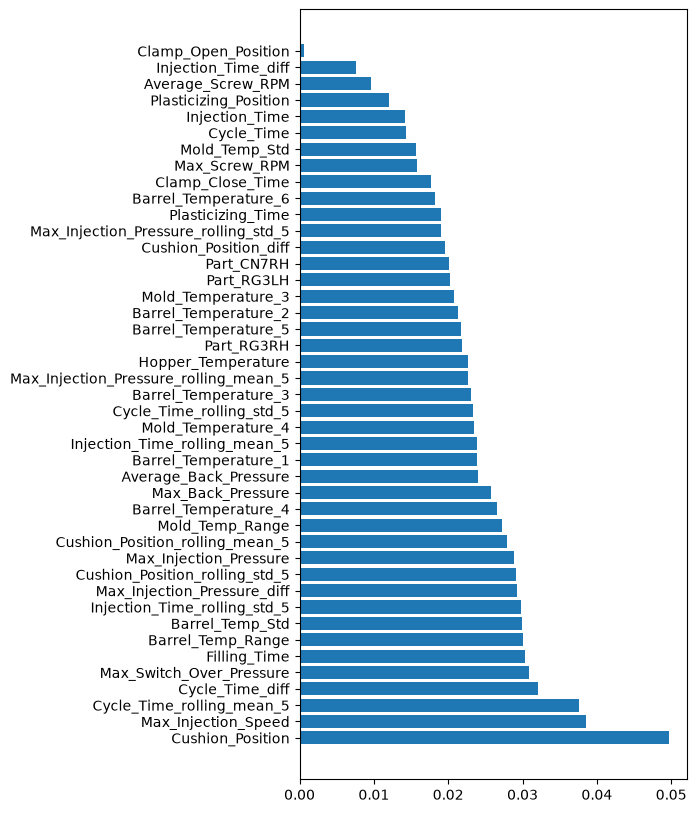

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 10))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.show()